## Importing Libraries

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
import re
import string

# HTML cleaning
from bs4 import BeautifulSoup

# Stopwords
from nltk.corpus import stopwords

# Tokenization
from nltk.tokenize import word_tokenize

# Lemmatization
from nltk.stem import WordNetLemmatizer

# Word frequency
from collections import Counter

# WordCloud
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Save model
import joblib

## Downloading NLTK data

In [4]:
nltk.download('punkt')

nltk.download('stopwords')

nltk.download('wordnet')

nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


True

In [5]:
df = pd.read_csv("../data/IMDB Dataset.csv")

In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.shape

(50000, 2)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [9]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(418)

In [11]:
df = df.drop_duplicates()

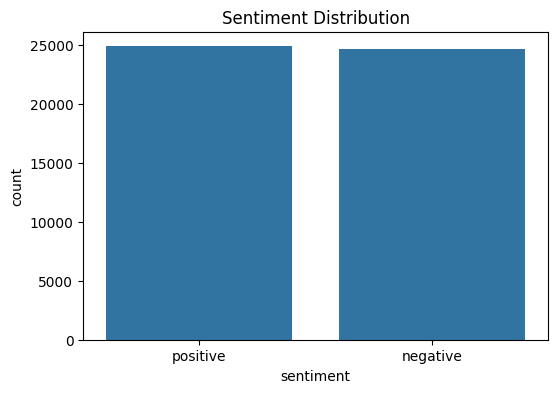

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='sentiment',
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

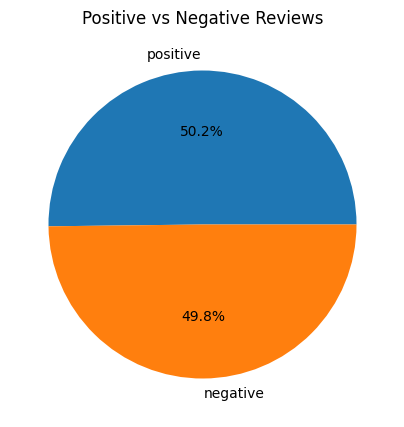

In [13]:
df['sentiment'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5)
)

plt.title("Positive vs Negative Reviews")

plt.ylabel("")

plt.show()

In [23]:
# Stopwords
stop_words = set(stopwords.words('english'))

# Lemmatizer
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = BeautifulSoup(
        text,
        "html.parser"
    ).get_text()

    # Remove URLs
    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )

    # Remove emojis
    text = re.sub(
        r'[^\x00-\x7F]+',
        '',
        text
    )

    # Remove numbers
    text = re.sub(
        r'\d+',
        '',
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # Join words
    cleaned_text = " ".join(tokens)

    return cleaned_text

In [24]:
df['clean_review'] = df['review'].apply(clean_text)

In [25]:
df[
    ['review',
     'clean_review']
].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [26]:
sample_review = df['clean_review'][0]

print(sample_review)

one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home manyaryans muslim gangsta latino christian italian irish moreso scuffle death stare dodgy dealing shady agreement never far awayi would say main appeal show due fact go show wouldnt dare forget pretty picture painted mainstream audience forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard wholl sold nickel inmate wholl kill order get away well mannered middle class inmate turned prison bitc

In [27]:
tokens = word_tokenize(sample_review)

print(tokens)

['one', 'reviewer', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'methe', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scene', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violence', 'hardcore', 'classic', 'use', 'wordit', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focus', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'manyaryans', 'muslim', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'moreso', 'scuffle', 'death', 'stare', 'dodgy', 'dealing', 'shady', 'agreement', 'never', 'far', 'awayi', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'go', 'show', 'wouldnt', 'dare', 'forget', 'pretty', 'picture', 'painted', 'mainstream', 'audience', 'forget', 

In [31]:
df['char_count'] = df['clean_review'].apply(len)

df['word_count'] = df['clean_review'].apply(
    lambda x: len(x.split())
)

df['sentence_count'] = df['review'].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

df[
    ['char_count',
     'word_count',
     'sentence_count']
].describe()

,char_count,word_count,sentence_count
count,49582.000000,49582.000000,49582.000000
mean,820.160683,118.673470,10.741519
std,632.706342,89.331493,7.817026
min,17.000000,3.000000,1.000000
25%,429.000000,64.000000,6.000000
50%,603.000000,88.000000,9.000000
75%,1000.000000,144.000000,13.000000
max,9182.000000,1420.000000,282.000000


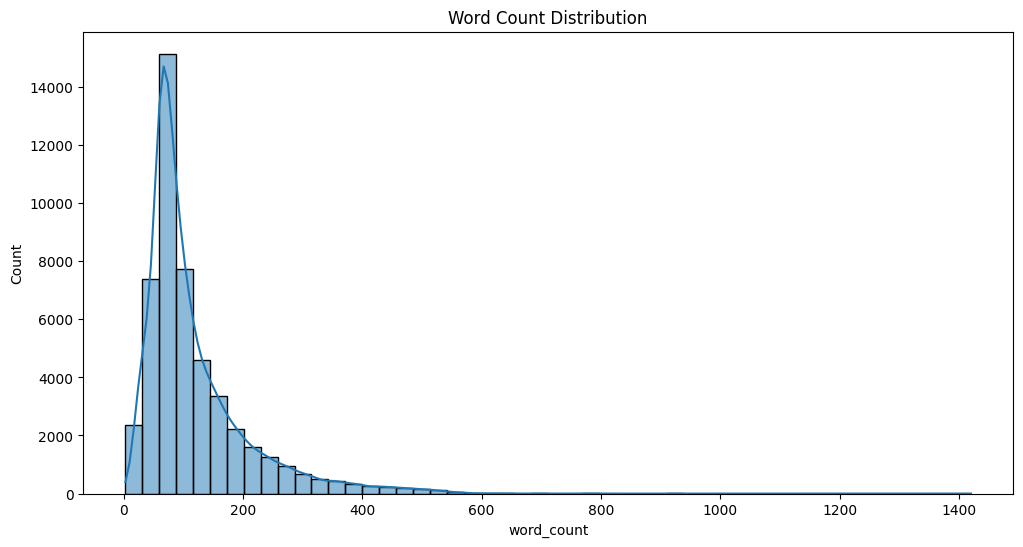

In [32]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['word_count'],
    bins=50,
    kde=True
)

plt.title("Word Count Distribution")

plt.show()

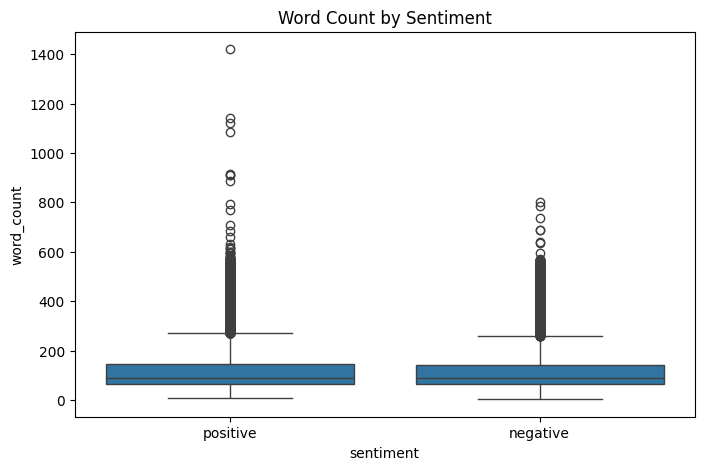

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='sentiment',
    y='word_count',
    data=df
)

plt.title("Word Count by Sentiment")

plt.show()

In [34]:
positive_reviews = df[
    df['sentiment'] == 'positive'
]['clean_review']

positive_text = " ".join(
    positive_reviews
)

In [44]:
positive_words = positive_text.split()

positive_freq = Counter(
    positive_words
).most_common(10)

positive_freq

[('film', 47737),
 ('movie', 42931),
 ('one', 26845),
 ('like', 17478),
 ('time', 15135),
 ('good', 14363),
 ('story', 13610),
 ('character', 13568),
 ('great', 12621),
 ('see', 12480)]

In [45]:
positive_df = pd.DataFrame(
    positive_freq,
    columns=['Word', 'Frequency']
)

positive_df

,Word,Frequency
0,film,47737
1,movie,42931
2,one,26845
3,like,17478
4,time,15135
5,good,14363
6,story,13610
7,character,13568
8,great,12621
9,see,12480


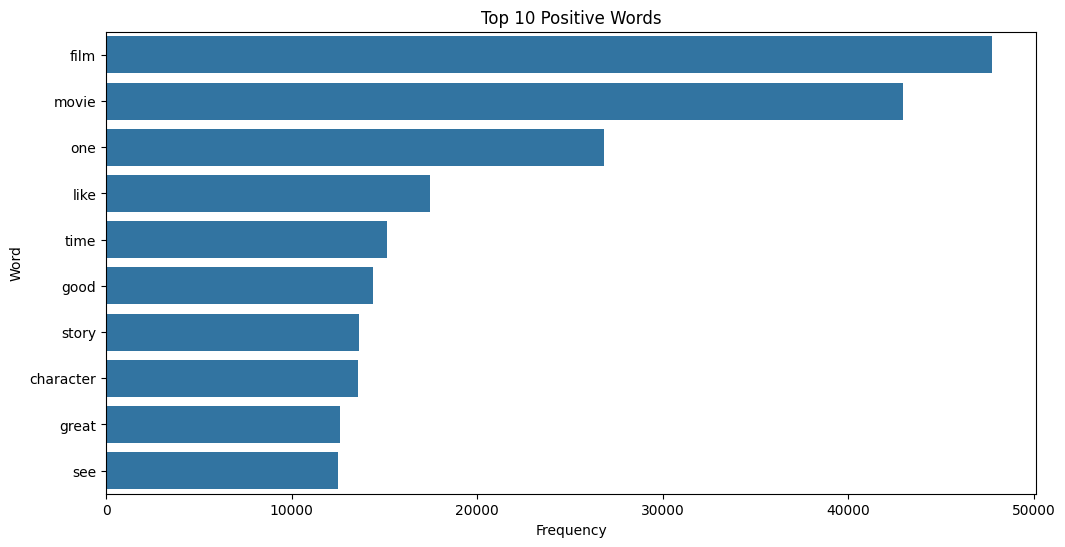

In [51]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=positive_df
)

plt.title("Top 10 Positive Words")

plt.show()

In [47]:
negative_reviews = df[
    df['sentiment'] == 'negative'
]['clean_review']

negative_text = " ".join(
    negative_reviews
)

In [48]:
negative_words = negative_text.split()

negative_freq = Counter(
    negative_words
).most_common(10)

negative_freq

[('movie', 55337),
 ('film', 41449),
 ('one', 25431),
 ('like', 21976),
 ('even', 14763),
 ('good', 14052),
 ('time', 14014),
 ('bad', 13931),
 ('character', 13775),
 ('would', 13483)]

In [49]:
negative_df = pd.DataFrame(
    negative_freq,
    columns=['Word', 'Frequency']
)

negative_df

,Word,Frequency
0,movie,55337
1,film,41449
2,one,25431
3,like,21976
4,even,14763
5,good,14052
6,time,14014
7,bad,13931
8,character,13775
9,would,13483


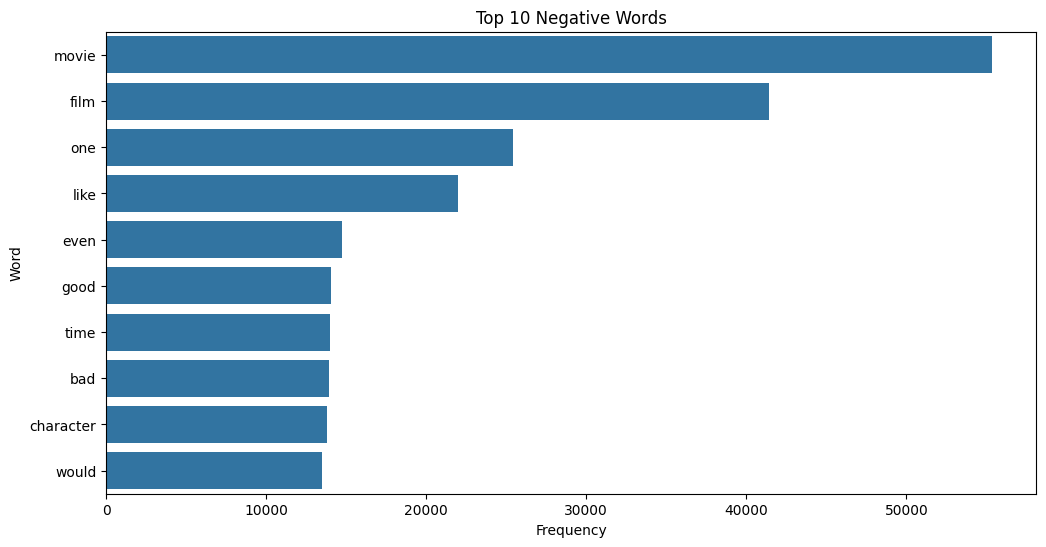

In [50]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=negative_df
)

plt.title("Top 10 Negative Words")

plt.show()

In [52]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(positive_text)

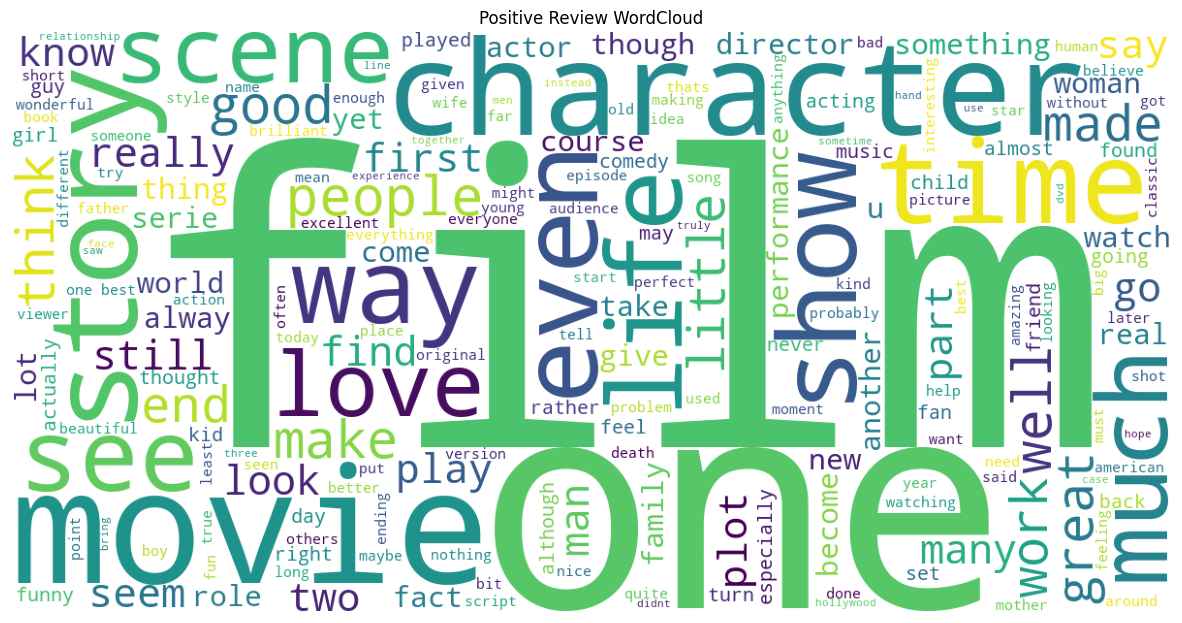

In [53]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Review WordCloud")

plt.show()

In [54]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='black'
).generate(negative_text)

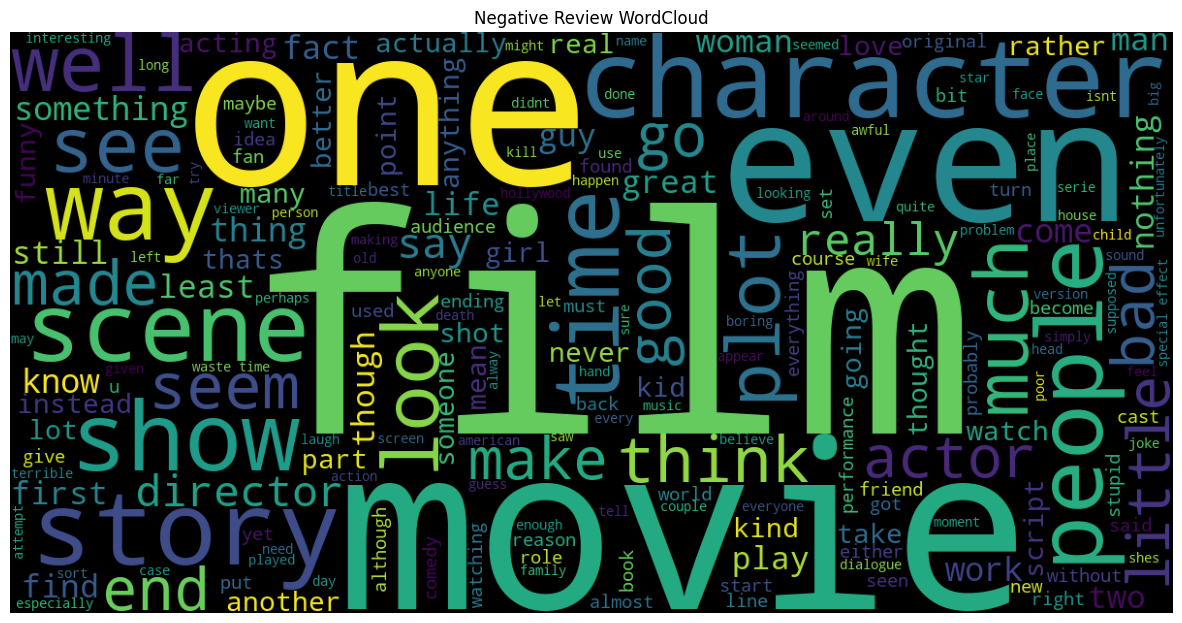

In [55]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Negative Review WordCloud")

plt.show()

In [56]:
from sklearn.feature_extraction.text import CountVectorizer

bigram = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

bigram_matrix = bigram.fit_transform(
    df['clean_review']
)

bigram_df = pd.DataFrame(
    bigram_matrix.toarray(),
    columns=bigram.get_feature_names_out()
)

bigram_counts = bigram_df.sum().sort_values(
    ascending=False
)

bigram_counts.head(15)

look like         2854
ever seen         2521
special effect    2190
ive seen          2127
dont know         2040
main character    1857
even though       1849
one best          1834
year old          1731
movie like        1703
movie ever        1535
horror movie      1490
see movie         1481
good movie        1458
waste time        1424
dtype: int64

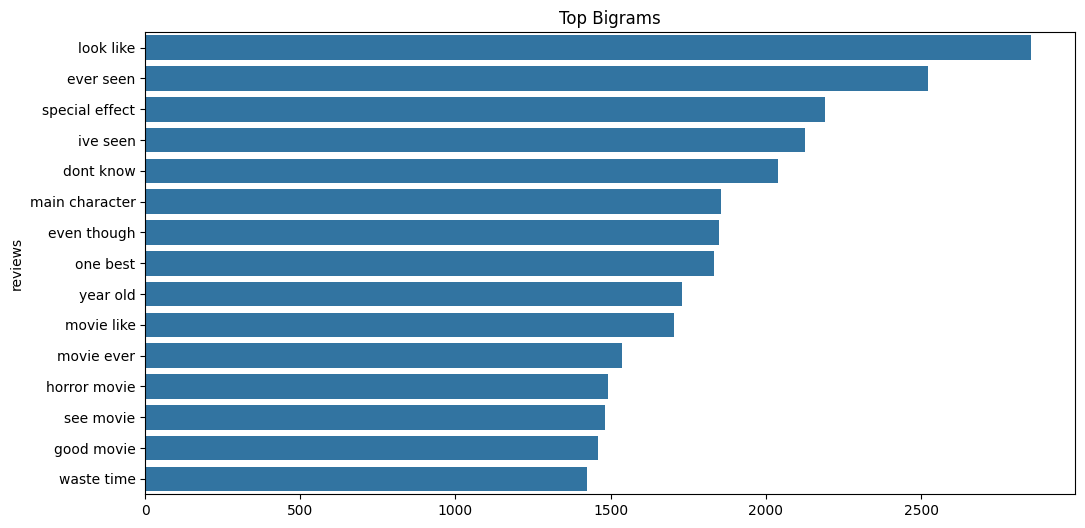

In [59]:
top_bigram = bigram_counts.head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_bigram.values,
    y=top_bigram.index
)

plt.title("Top Bigrams")
plt.ylabel("reviews")

plt.show()

In [60]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(
    max_features=5000
)

X_bow = bow.fit_transform(
    df['clean_review']
)

X_bow.shape

(49582, 5000)

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df['clean_review']
)

y = df['sentiment']

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(X_test)

from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression Accuracy:",
      lr_accuracy)

Logistic Regression Accuracy: 0.883029141877584


In [64]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train,
    y_train
)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

print("Naive Bayes Accuracy:",
      nb_accuracy)

Naive Bayes Accuracy: 0.8504588081072905


In [65]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:",
      rf_accuracy)

Random Forest Accuracy: 0.8381567006151054


In [66]:
accuracy_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Random Forest'
    ],

    'Accuracy': [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy
    ]
})

accuracy_df

,Model,Accuracy
0,Logistic Regression,0.883029
1,Naive Bayes,0.850459
2,Random Forest,0.838157


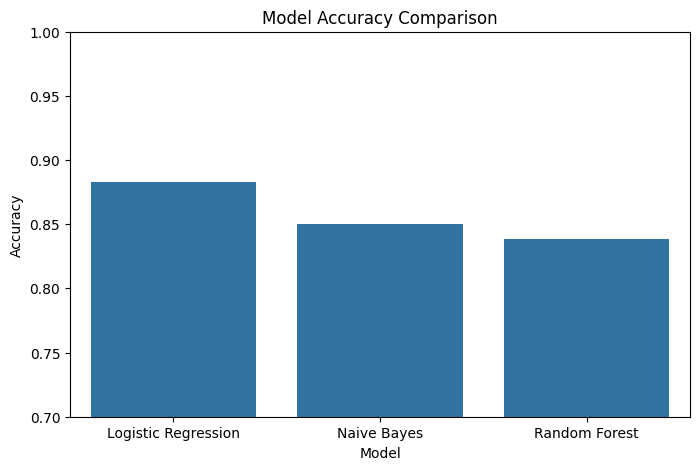

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=accuracy_df
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.7,1.0)

plt.show()

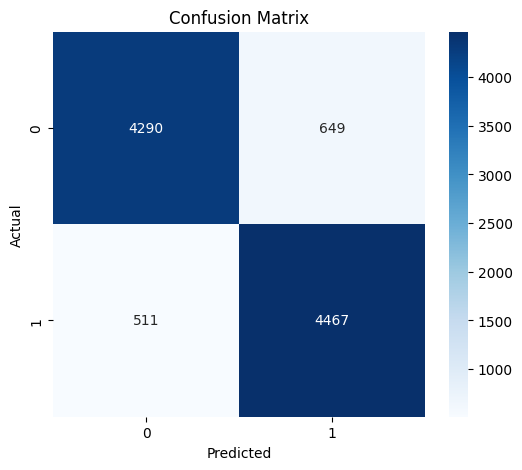

In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [69]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4939
    positive       0.87      0.90      0.89      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



In [70]:
import joblib

joblib.dump(
    lr_model,
    "sentiment_model.pkl"
)

['sentiment_model.pkl']

In [71]:
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']